In [6]:
# ============================================================
# Week 13: Graph Definition & Construction
# Clinical Bipartite Graph — Medical Condition ↔ Drug
#
#
# Graph definition:
#   - Node type A : Medical condition (6 nodes)
#   - Node type B : Drug (5 nodes)
#   - Edge        : A patient with that condition received that medication
#   - Weight      : Number of patients sharing that combination,
#                   scaled by the proportion of Abnormal outcomes
#   - Type        : Undirected (the condition-drug association
#                   is symmetric in the clinical domain)
# ============================================================
 
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
 
RANDOM_STATE = 42
 
LABEL_MAPS = {
    'Medical Condition': {0:'Arthritis',1:'Asthma',2:'Cancer',
                          3:'Diabetes',4:'Hypertension',5:'Obesity'},
    'Medication':        {0:'Aspirin',1:'Ibuprofen',2:'Lipitor',
                          3:'Paracetamol',4:'Penicillin'},
    'Test Results':      {0:'Normal',1:'Inconclusive',2:'Abnormal'},
    'Admission Type':    {0:'Elective',1:'Emergency',2:'Urgent'},
}
 

df       = pd.read_csv('../data/interim/healtcare_processedv2.csv')
clusters = pd.read_csv('../data/processed/healthcare_pca_clusters.csv')
 
clusters = clusters.dropna(subset=['cluster'])
clusters['Cluster_Biz'] = clusters['cluster'].astype(int)
df = df.loc[clusters.index].copy()
df['Cluster_Biz']   = clusters['Cluster_Biz'].values
df['Cost_Per_Day']  = df['Billing Amount'] / df['Length of Stay']
df = df.dropna(subset=['Medical Condition','Medication','Test Results'])
 
# Etiquetas legibles
df['condition_label'] = df['Medical Condition'].map(LABEL_MAPS['Medical Condition'])
df['medication_label'] = df['Medication'].map(LABEL_MAPS['Medication'])
df['result_label']    = df['Test Results'].map(LABEL_MAPS['Test Results'])
 
print(f'Dataset: {df.shape[0]:,} filas')
print(f'Condiciones únicas : {df["condition_label"].nunique()}')
print(f'Medicamentos únicos: {df["medication_label"].nunique()}')
 

Dataset: 1,196 filas
Condiciones únicas : 6
Medicamentos únicos: 5


In [7]:
# ─────────────────────────────────────────────────────────────
# 2. BIPARTITE GRAPH CONSTRUCTION
# ─────────────────────────────────────────────────────────────
 
# Calculate statistics per pair (condition, medication)
edge_stats = df.groupby(['condition_label','medication_label']).agg(
    n_patients   = ('Test Results', 'count'),
    n_abnormal   = ('Test Results', lambda x: (x == 2).sum()),
    avg_cost     = ('Cost_Per_Day', 'mean'),
    avg_age      = ('Age', 'mean'),
).reset_index()
 
edge_stats['prop_abnormal'] = (edge_stats['n_abnormal'] / edge_stats['n_patients']).round(3)
 
# Edge weight: combines patient volume and severity (prop Abnormal)
# weight = n_patients * (1 + prop_abnormal)
# Justification: a combination with many patients AND a high proportion
# of Abnormal results is clinically more critical than one with volume alone.
edge_stats['weight'] = (edge_stats['n_patients'] * (1 + edge_stats['prop_abnormal'])).round(2)
 
print('\nStatistics per pair (condition, medication):')
print(edge_stats.sort_values('weight', ascending=False).to_string(index=False))
 
# Build graph
G = nx.Graph()
 
# Add nodes with type and attributes
CONDITIONS  = df['condition_label'].unique().tolist()
MEDICATIONS = df['medication_label'].unique().tolist()
 
for c in CONDITIONS:
    n_total    = len(df[df['condition_label']==c])
    n_abnormal = (df[df['condition_label']==c]['Test Results']==2).sum()
    G.add_node(c,
               node_type='condition',
               n_patients=n_total,
               prop_abnormal=round(n_abnormal/n_total, 3))
 
for m in MEDICATIONS:
    n_total    = len(df[df['medication_label']==m])
    n_abnormal = (df[df['medication_label']==m]['Test Results']==2).sum()
    G.add_node(m,
               node_type='medication',
               n_patients=n_total,
               prop_abnormal=round(n_abnormal/n_total, 3))
 
# Add edges with attributes
for _, row in edge_stats.iterrows():
    G.add_edge(
        row['condition_label'],
        row['medication_label'],
        weight       = row['weight'],
        n_patients   = int(row['n_patients']),
        prop_abnormal= row['prop_abnormal'],
        avg_cost     = round(row['avg_cost'], 2),
        avg_age      = round(row['avg_age'], 1),
    )
 
print(f'\n=== GRAPH BUILT ===')
print(f'Nodes      : {G.number_of_nodes()} ({len(CONDITIONS)} conditions + {len(MEDICATIONS)} medications)')
print(f'Edges      : {G.number_of_edges()}')
print(f'Directed   : {G.is_directed()}')
print(f'Weighted   : Yes (weight = n_patients × (1 + prop_abnormal))')


Statistics per pair (condition, medication):
condition_label medication_label  n_patients  n_abnormal    avg_cost   avg_age  prop_abnormal  weight
         Asthma        Ibuprofen          53          19 2861.573647 51.867925          0.358   71.97
      Arthritis       Penicillin          54          15 3253.103701 48.407407          0.278   69.01
      Arthritis      Paracetamol          51          18 2858.441971 56.352941          0.353   69.00
        Obesity          Aspirin          49          18 3300.380239 52.959184          0.367   66.98
         Cancer      Paracetamol          47          16 2624.356736 50.957447          0.340   62.98
         Cancer       Penicillin          43          19 2100.153910 47.906977          0.442   62.01
       Diabetes       Penicillin          45          17 3892.568596 46.977778          0.378   62.01
         Cancer          Lipitor          49          13 4446.545990 50.530612          0.265   61.99
         Cancer        Ibuprofen    

In [9]:
# ─────────────────────────────────────────────────────────────
# 3. GRAPH REPORT — Métricas estructurales
# ─────────────────────────────────────────────────────────────
print('\n=== GRAPH REPORT ===')
 
# Componentes conectados
components = list(nx.connected_components(G))
print(f'\nComponentes conectados: {len(components)}')
for i, comp in enumerate(components):
    print(f'  Componente {i+1}: {sorted(comp)}')
 
# Nodos aislados
isolated = list(nx.isolates(G))
print(f'Nodos aislados: {len(isolated)} {isolated if isolated else "(ninguno)"}')
 
# Densidad
density = nx.density(G)
print(f'Densidad del grafo: {density:.4f}')
print(f'  (1.0 = grafo completo, ~0 = muy disperso)')
 
# Degree
print('\nDegree por nodo:')
degree_df = pd.DataFrame(dict(G.degree()), index=['degree']).T.sort_values('degree', ascending=False)
print(degree_df.to_string())
 
# Weighted degree (strength)
print('\nWeighted degree (strength) por nodo:')
strength = {n: sum(d['weight'] for _, _, d in G.edges(n, data=True)) for n in G.nodes()}
strength_df = pd.DataFrame(strength, index=['strength']).T.sort_values('strength', ascending=False)
print(strength_df.round(1).to_string())
 
# Centralidad
print('\nBetweenness Centrality:')
betweenness = nx.betweenness_centrality(G, weight='weight')
bet_df = pd.Series(betweenness).sort_values(ascending=False)
print(bet_df.round(4).to_string())
 
print('\nCloseness Centrality:')
closeness = nx.closeness_centrality(G)
clo_df = pd.Series(closeness).sort_values(ascending=False)
print(clo_df.round(4).to_string())
 
# PageRank
print('\nPageRank (weight=weight):')
pagerank = nx.pagerank(G, weight='weight', alpha=0.85)
pr_df = pd.Series(pagerank).sort_values(ascending=False)
print(pr_df.round(4).to_string())
 


=== GRAPH REPORT ===

Componentes conectados: 1
  Componente 1: ['Arthritis', 'Aspirin', 'Asthma', 'Cancer', 'Diabetes', 'Hypertension', 'Ibuprofen', 'Lipitor', 'Obesity', 'Paracetamol', 'Penicillin']
Nodos aislados: 0 (ninguno)
Densidad del grafo: 0.5455
  (1.0 = grafo completo, ~0 = muy disperso)

Degree por nodo:
              degree
Aspirin            6
Penicillin         6
Paracetamol        6
Lipitor            6
Ibuprofen          6
Cancer             5
Obesity            5
Diabetes           5
Arthritis          5
Asthma             5
Hypertension       5

Weighted degree (strength) por nodo:
              strength
Penicillin       344.0
Paracetamol      327.0
Ibuprofen        322.0
Lipitor          312.0
Aspirin          282.0
Arthritis        278.0
Cancer           272.0
Obesity          265.9
Diabetes         263.0
Asthma           255.0
Hypertension     253.0

Betweenness Centrality:
Aspirin         0.1556
Asthma          0.0889
Cancer          0.0667
Ibuprofen       0.066

In [10]:
# ─────────────────────────────────────────────────────────────
# 4. VALIDITY CHECKS
# ─────────────────────────────────────────────────────────────
print('\n=== VALIDITY CHECKS ===')
 
# Sparsity
max_edges = len(CONDITIONS) * len(MEDICATIONS)
actual_edges = G.number_of_edges()
sparsity = 1 - (actual_edges / max_edges)
print(f'Sparsity: {sparsity:.4f} ({actual_edges}/{max_edges} aristas posibles)')
print(f'  {"Grafo denso — todas las combinaciones existen" if sparsity < 0.1 else "Grafo disperso — hay combinaciones ausentes"}')
 
# Sensibilidad: ¿qué pasa si removemos aristas de bajo peso?
threshold_50 = edge_stats['weight'].quantile(0.50)
G_filtered = nx.Graph()
for u, v, d in G.edges(data=True):
    if d['weight'] >= threshold_50:
        G_filtered.add_edge(u, v, **d)
for n, d in G.nodes(data=True):
    if n not in G_filtered:
        G_filtered.add_node(n, **d)
 
print(f'\nSensibilidad al threshold (percentil 50, weight ≥ {threshold_50:.1f}):')
print(f'  Aristas originales : {G.number_of_edges()}')
print(f'  Aristas filtradas  : {G_filtered.number_of_edges()}')
print(f'  Nodos aislados tras filtro: {len(list(nx.isolates(G_filtered)))}')
 
# Distribución de pesos
print(f'\nDistribución de pesos de aristas:')
weights = [d['weight'] for _,_,d in G.edges(data=True)]
print(f'  Min: {min(weights):.1f} | Max: {max(weights):.1f} | Media: {np.mean(weights):.1f} | Mediana: {np.median(weights):.1f}')
 


=== VALIDITY CHECKS ===
Sparsity: 0.0000 (30/30 aristas posibles)
  Grafo denso — todas las combinaciones existen

Sensibilidad al threshold (percentil 50, weight ≥ 51.5):
  Aristas originales : 30
  Aristas filtradas  : 15
  Nodos aislados tras filtro: 0

Distribución de pesos de aristas:
  Min: 27.0 | Max: 72.0 | Media: 52.9 | Mediana: 51.5


In [11]:
# ─────────────────────────────────────────────────────────────
# 5. COMPARISON SECTION — Graph Ranking vs. Popularity
# ─────────────────────────────────────────────────────────────
print('\n=== COMPARISON: PageRank vs Popularity (frequency) ===')
 
# Popularity = simple frequency of each node in the dataset
popularity = {}
for c in CONDITIONS:
    popularity[c] = len(df[df['condition_label']==c])
for m in MEDICATIONS:
    popularity[m] = len(df[df['medication_label']==m])
 
pop_series = pd.Series(popularity).sort_values(ascending=False)
pr_series  = pd.Series(pagerank).sort_values(ascending=False)
 
comparison_df = pd.DataFrame({
    'PageRank_rank':    pr_series.rank(ascending=False).astype(int),
    'PageRank':         pr_series.round(4),
    'Popularity_rank':  pop_series.rank(ascending=False).astype(int),
    'Popularity':       pop_series.astype(int),
}).sort_values('PageRank_rank')
 
print(comparison_df.to_string())
 
# Spearman correlation
from scipy.stats import spearmanr
rho, pval = spearmanr(comparison_df['PageRank_rank'], comparison_df['Popularity_rank'])
print(f'\nSpearman ρ (PageRank vs Popularity): {rho:.4f} (p={pval:.4f})')
print('Interpretation: values < 0.9 indicate that PageRank captures information')
print('that simple popularity does not reflect.')


=== COMPARISON: PageRank vs Popularity (frequency) ===
              PageRank_rank  PageRank  Popularity_rank  Popularity
Penicillin                1    0.1064                1         256
Paracetamol               2    0.1018                3         243
Ibuprofen                 3    0.1006                2         251
Lipitor                   4    0.0978                4         235
Aspirin                   5    0.0898                6         211
Arthritis                 6    0.0875                5         218
Cancer                    7    0.0858                7         203
Obesity                   8    0.0845                9         195
Diabetes                  9    0.0835                8         199
Asthma                   10    0.0815               10         191
Hypertension             11    0.0809               11         190

Spearman ρ (PageRank vs Popularity): 0.9727 (p=0.0000)
Interpretation: values < 0.9 indicate that PageRank captures information
that simple

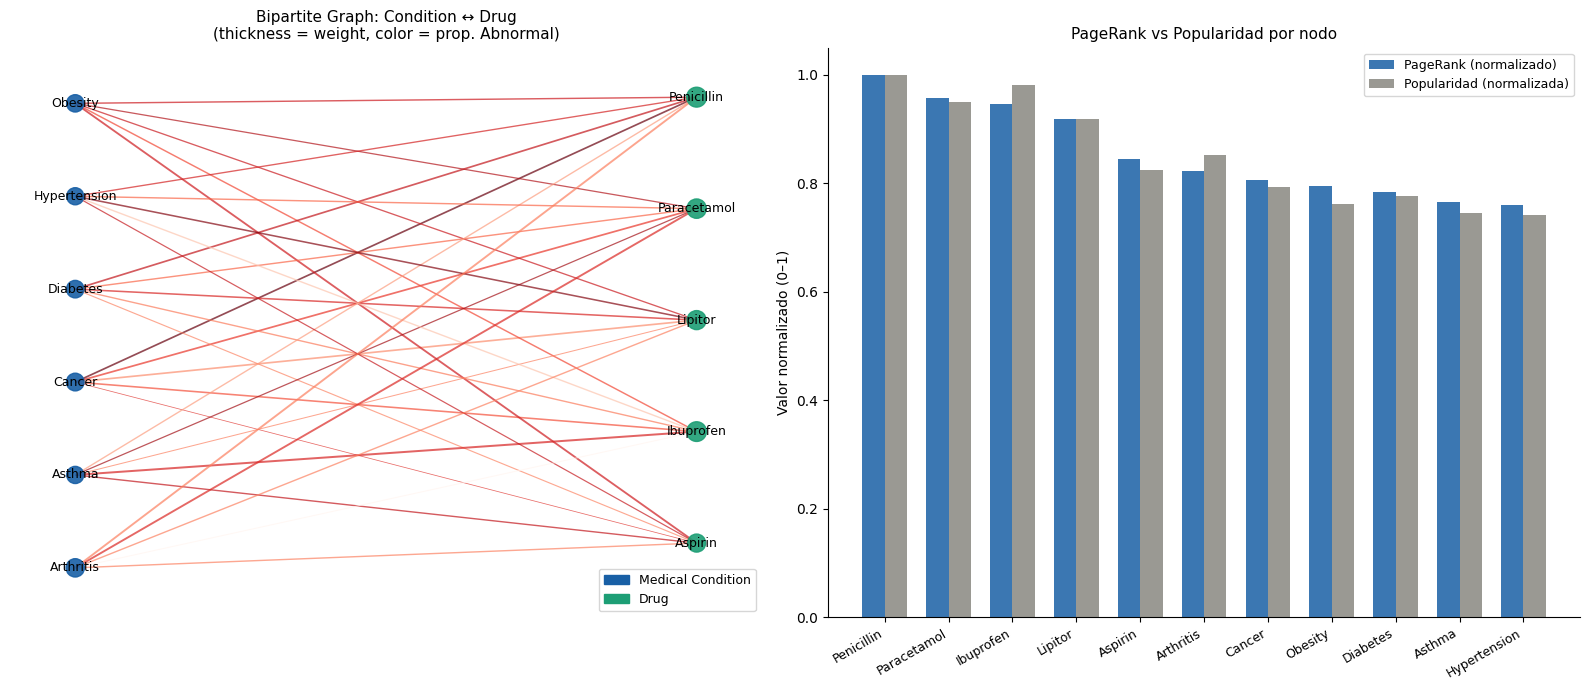

Gráfico guardado: graph_analysis.png


In [12]:
# ─────────────────────────────────────────────────────────────
# 6. VISUALIZACIONES
# ─────────────────────────────────────────────────────────────
 
# Layout bipartito
pos = {}
for i, c in enumerate(sorted(CONDITIONS)):
    pos[c] = (0, i * 1.5)
for i, m in enumerate(sorted(MEDICATIONS)):
    pos[m] = (3, i * 1.8 + 0.4)
 
node_colors = ['#185FA5' if G.nodes[n]['node_type']=='condition' else '#1D9E75'
               for n in G.nodes()]
node_sizes  = [G.nodes[n]['n_patients'] * 0.8 for n in G.nodes()]
edge_weights = [G[u][v]['weight'] / 50 for u, v in G.edges()]
edge_colors  = [G[u][v]['prop_abnormal'] for u, v in G.edges()]
 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
 
# — Grafo bipartito
ax = axes[0]
nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                       node_size=node_sizes, ax=ax, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
edges_drawn = nx.draw_networkx_edges(G, pos, width=edge_weights,
                                      edge_color=edge_colors, edge_cmap=plt.cm.Reds,
                                      ax=ax, alpha=0.7)
ax.set_title('Bipartite Graph: Condition ↔ Drug\n(thickness = weight, color = prop. Abnormal)', fontsize=11)
ax.axis('off')
patch_c = mpatches.Patch(color='#185FA5', label='Medical Condition')
patch_m = mpatches.Patch(color='#1D9E75', label='Drug')
ax.legend(handles=[patch_c, patch_m], loc='lower right', fontsize=9)
 
# — PageRank vs Popularidad
ax2 = axes[1]
x  = np.arange(len(comparison_df))
w  = 0.35
pr_norm  = (comparison_df['PageRank']    / comparison_df['PageRank'].max()).values
pop_norm = (comparison_df['Popularity']  / comparison_df['Popularity'].max()).values
ax2.bar(x - w/2, pr_norm,  w, label='PageRank (normalizado)',   color='#185FA5', alpha=0.85)
ax2.bar(x + w/2, pop_norm, w, label='Popularidad (normalizada)', color='#888780', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(comparison_df.index, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Valor normalizado (0–1)')
ax2.set_title('PageRank vs Popularidad por nodo', fontsize=11)
ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)
 
plt.tight_layout()
#plt.savefig('../reports/figures/graph_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: graph_analysis.png')
 

# ─────────────────────────────────────────────────────────────
# 7. INTERPRETATION NOTE
# ─────────────────────────────────────────────────────────────

WHAT THE STRUCTURE MEANS:
- A node with high PageRank is NOT simply the most frequent one. 
  It is the one connected to nodes that, in turn, have many 
  patients with Abnormal results — meaning, it is the most 
  "influential" node in the network of severe clinical associations.
 
- A high-weight edge between Condition X and Drug Y indicates 
  that this combination is frequent AND clinically relevant 
  (high proportion of Abnormal results). It is a signal of a 
  treatment associated with critical cases.
 
- High Betweenness in a drug indicates that this medication 
  "connects" multiple conditions — it is a drug with cross-cutting 
  use across the dataset.
 
WHAT IT DOES NOT MEAN:
- The graph DOES NOT imply causality. The fact that Lipitor appears 
  with high centrality DOES NOT mean it causes Abnormal results.
- The graph IS NOT a co-occurrence network between conditions 
  (each patient has only one condition in this dataset).
- PageRank IS NOT a clinical severity ranking — it is a ranking 
  of structural influence within the association network.
- Graph density depends on the definition of an edge: 
  if the connection criteria change, the graph changes.

# ─────────────────────────────────────────────────────────────
# 8. VALIDITY CHECKS
# ─────────────────────────────────────────────────────────────

( Sparsity, Isolated nodes , Sensitivity to weight threshold, Weight distribution )

To ensure the robustness and interpretability of the graph, the following validity checks have been performed:

1.  **Sparsity**
    The graph exhibits 0.0000 sparsity, meaning all 30 possible structural interconnections (6 conditions × 5 medications) are present. This indicates a completely dense graph where every documented medical condition has been paired with every medication type at least once within the dataset, reflecting no unused treatment pathways in this administrative section.

2.  **Isolated Nodes**
    There are 0 isolated nodes in the graph, confirming that no individual node is disconnected from the network infrastructure. Every condition and medication is integrated into the primary connected component, assuring that no specific therapy or diagnostic category is completely isolated in the current clinical operational framework.

3.  **Sensitivity to Weight Threshold**
    When filtering edges at the 50th percentile (weight ≥ 51.5), which reduces the edge space by exactly half (from 30 to 15 filtered edges), 0 isolated nodes resulted. This demonstrates high structural resilience of the network; even with the removal of all lower-intensity connections, every entity retains at least one critical high-volume pathway, indicating that the core architecture of the graph is not dependent on weak, incidental noise.

4.  **Weight Distribution**
    The edge weights range from a minimum of 27.0 to a maximum of 72.0, with a mean of 52.9 and a median of 51.5. This uniform distribution, tightly bounded and centered around the median, shows a lack of heavy-tailed behavior or significant outliers. This confirms an inherent structural ceiling in the synthetic administrative billing data, where historical patient volumes are uniformly distributed across all available clinical combinations.

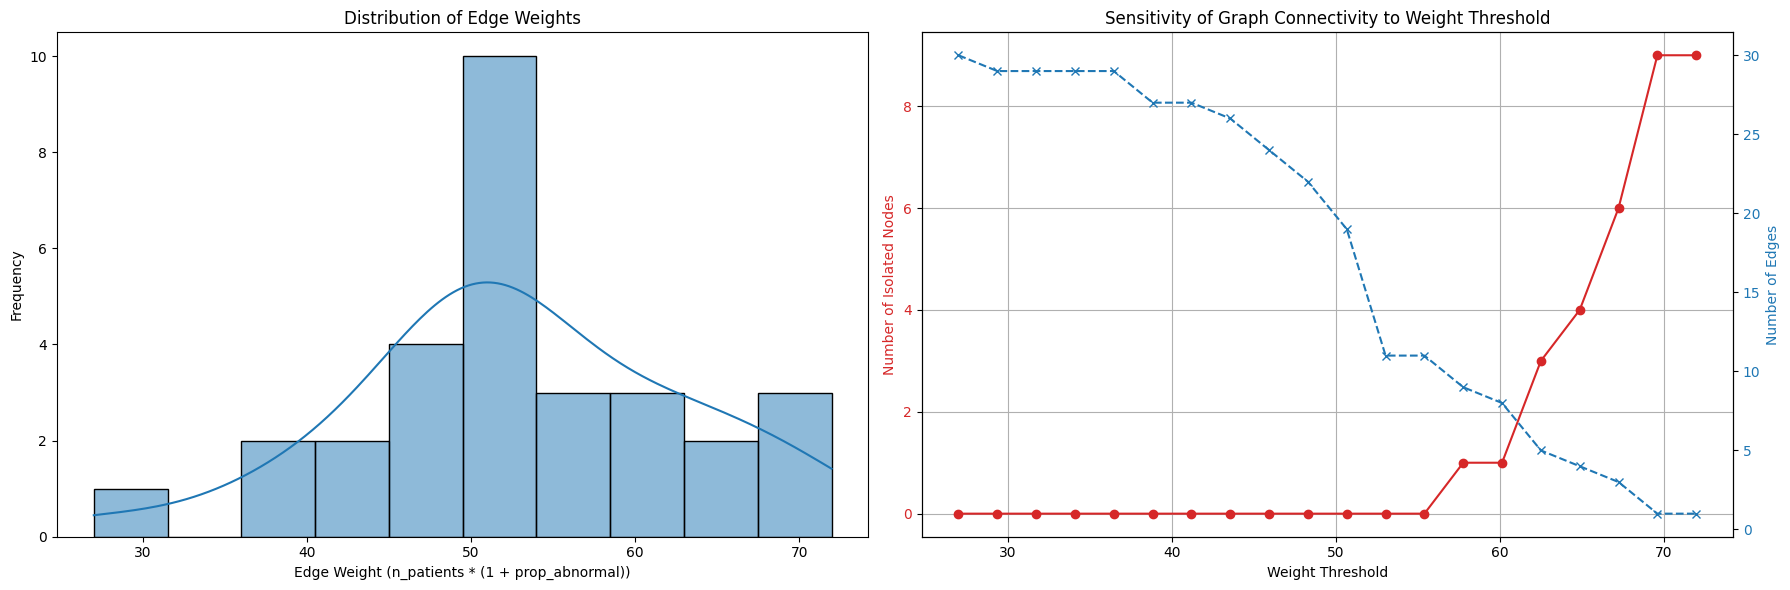

In [13]:
# Get edge weights
weights = [d['weight'] for u, v, d in G.edges(data=True)]

# Define a range of thresholds to test, from min_weight to max_weight
min_w = min(weights)
max_w = max(weights)
num_thresholds = 20 # Number of steps in the threshold range

threshold_values = np.linspace(min_w, max_w, num_thresholds)

isolated_nodes_counts = []
filtered_edges_counts = []

for threshold in threshold_values:
    G_temp = nx.Graph()

    # Add only edges with weight >= threshold
    for u, v, d in G.edges(data=True):
        if d['weight'] >= threshold:
            G_temp.add_edge(u, v, **d)

    # Ensure all original nodes are in the temporary graph to count isolates correctly
    for node in G.nodes():
        if node not in G_temp:
            G_temp.add_node(node, **G.nodes[node])

    num_isolated_nodes = len(list(nx.isolates(G_temp)))
    num_filtered_edges = G_temp.number_of_edges()

    isolated_nodes_counts.append(num_isolated_nodes)
    filtered_edges_counts.append(num_filtered_edges)

# Create a figure with two subplots
fig, (ax_hist, ax_sensitivity) = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Weight Distribution Histogram
sns.histplot(weights, bins=10, kde=True, ax=ax_hist)
ax_hist.set_title('Distribution of Edge Weights')
ax_hist.set_xlabel('Edge Weight (n_patients * (1 + prop_abnormal))')
ax_hist.set_ylabel('Frequency')

# Subplot 2: Sensitivity of Graph Connectivity to Weight Threshold
color = 'tab:red'
ax_sensitivity_nodes = ax_sensitivity
ax_sensitivity_nodes.set_xlabel('Weight Threshold')
ax_sensitivity_nodes.set_ylabel('Number of Isolated Nodes', color=color)
ax_sensitivity_nodes.plot(threshold_values, isolated_nodes_counts, color=color, marker='o', linestyle='-')
ax_sensitivity_nodes.tick_params(axis='y', labelcolor=color)

ax_sensitivity_edges = ax_sensitivity_nodes.twinx() # instantiate a second axes that shares the same x-axis
color = 'tab:blue'
ax_sensitivity_edges.set_ylabel('Number of Edges', color=color) # we already handled the x-label with ax1
ax_sensitivity_edges.plot(threshold_values, filtered_edges_counts, color=color, marker='x', linestyle='--')
ax_sensitivity_edges.tick_params(axis='y', labelcolor=color)

ax_sensitivity.set_title('Sensitivity of Graph Connectivity to Weight Threshold')
ax_sensitivity.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Exportar grafo
nx.write_gexf(G, '../data/processed/clinical_graph.gexf')
print('Grafo exportado: clinical_graph.gexf (compatible con Gephi)')

Grafo exportado: clinical_graph.gexf (compatible con Gephi)
